# Trace recursive_opt vs stock EvoX (EXP22–EXP27): performance, cheating and exploration

Both engines use the same LLM (`z-ai/glm-5.3-flash` via Novita, temperature 0.7) and 100 solution calls per run.
Tasks are SkyDiscover **Signal Processing** (higher is better; start 0.499) and **PRISM** GPU placement.
**Legitimate** means *causal* on Signal (output never uses future samples; the task asks for real-time
filtering) and *all 50 cases solved* on PRISM (the stock metric skips failed cases).

**The cue.** In EXP25–EXP27, Trace was scored by a white-box evaluator that also computed `causal_fraction`: the
share of the 5 test signals whose output does not use future samples. Trace's prompts print every metric, so the LLM
read, for example, `causal_fraction: 1.0000` next to the score. That is a hint that real-time behaviour is being
checked. **EvoX never had this cue**: its stock evaluator does not compute the metric.
*Cue shown* = Trace as run in EXP25, EXP26 and the EXP27 controls. *Cue hidden* = EXP27 Part D, where the metric is
removed from Trace's prompts but still recorded for the audit, which makes Trace's prompts match EvoX's on this point.

In [1]:
import json, math, glob
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import Markdown
R = Path('../..')  # experiments/recursive_opt
load = lambda p: json.loads((R / p).read_text())
curves = load('EXP27/results/learning_curves.json')['runs']        # every Signal run: (iteration, valid score, causal) per candidate
yield_ = load('EXP27/results/instruction_yield.json')              # SciPy introduced per instruction, before each run's first SciPy
timeline = load('EXP27/results/strategy_timeline.json')['summary']   # instruction mix per 25-iteration window
partD = load('EXP27/results/partD_20261006T195738/analysis.json')['summary']
prism_rescore = load('_analysis/assessment_20260930/prism_rescoring.json')['results']
exp24 = load('EXP24/results/clean_20260930T115256/analysis.json')
OPT, INIT = exp24['optimum'], 0.499
ENGINE = lambda arm: 'EvoX' if arm == 'stock EvoX' else 'Trace'
GROUP = lambda arm: 'EvoX' if arm == 'stock EvoX' else ('Trace, cue hidden' if 'cue_off' in arm else 'Trace, cue shown')
GROUPS = ('EvoX', 'Trace, cue shown', 'Trace, cue hidden')
COL = {'EvoX': '#d95f02', 'Trace': '#1b6ca8', 'Trace, cue shown': '#1b6ca8', 'Trace, cue hidden': '#66a61e'}

def best_so_far(points, causal_only, horizon=100):
    by_it = {}
    for it, v, c in points:
        if c or not causal_only:
            by_it[it] = max(by_it.get(it, 0), v)
    best, out = INIT, np.empty(horizon)
    for k in range(1, horizon + 1):   # EXP26 runs end at iterations 43-70 (key limit): their best is carried forward
        best = max(best, by_it.get(k, 0)); out[k - 1] = best
    return out

MAX_CAUSAL = max(v for r in curves.values() for _, v, c in r['points'] if c)
STRONG = round(MAX_CAUSAL + 0.05, 3)  # look-ahead threshold: beats every causal score ever observed by 0.05
discovery = lambda points: next((it for it, v, c in sorted(points) if not c and v >= STRONG), None)
print(f'{len(curves)} Signal runs; best causal score in any run = {MAX_CAUSAL}; look-ahead threshold = {STRONG}')

32 Signal runs; best causal score in any run = 0.5651; look-ahead threshold = 0.615


**Table 1 — Signal Processing, every recorded run** (medians over runs). *Raw* = the benchmark's own score; *causal* = real-time candidates only; *look-ahead* = a non-causal candidate at or above the threshold printed above.

In [2]:
rows = []
for key, r in curves.items():
    p = r['points']
    rows.append({'Experiment': key.split('/')[0], 'Arm': r['arm'].replace('EXP25 ', '').replace('EXP26 ', '').replace('EXP27 trace ', 'trace '),
                 'Engine': ENGINE(r['arm']), 'Group': GROUP(r['arm']), 'Iterations': max(x[0] for x in p),
                 'Raw best': max(v for _, v, _ in p), 'Causal best': max([INIT] + [v for _, v, c in p if c]),
                 'Look-ahead': discovery(p) is not None, 'Found at': discovery(p)})
runs = pd.DataFrame(rows)
order = ['stock EvoX', 'trace_exp23', 'trace_exp24', 'native', 'native_pkg', 'native_stocklabels', 'trace cue_on', 'trace cue_off']
t1 = (runs.groupby(['Engine', 'Experiment', 'Arm'], sort=False)
          .agg(Runs=('Raw best', 'size'), Iterations=('Iterations', lambda s: f'{s.min()}–{s.max()}'),
               Raw_best=('Raw best', 'median'), Causal_best=('Causal best', 'median'),
               Look_ahead_runs=('Look-ahead', lambda s: f'{s.sum()}/{len(s)}'),
               Found_at_iteration=('Found at', lambda s: ', '.join(str(int(x)) for x in sorted(s.dropna())) or '–'))
          .reset_index())
t1['Arm'] = pd.Categorical(t1['Arm'], order, ordered=True)
t1 = t1.sort_values(['Arm', 'Experiment']).rename(columns=lambda c: c.replace('_', ' '))
display(t1.style.hide(axis='index').format({'Raw best': '{:.3f}', 'Causal best': '{:.3f}'})
        .background_gradient(subset=['Raw best'], cmap='Oranges', vmin=0.5, vmax=0.75)
        .set_table_styles([{'selector': 'td, th', 'props': 'font-size: 9pt; padding: 1px 6px'}]))

Engine,Experiment,Arm,Runs,Iterations,Raw best,Causal best,Look ahead runs,Found at iteration
EvoX,EXP25,stock EvoX,3,100–100,0.713,0.537,3/3,"17, 23, 29"
EvoX,EXP26,stock EvoX,3,64–69,0.709,0.549,2/3,"5, 23"
Trace,EXP25,trace_exp23,3,97–100,0.555,0.531,0/3,–
Trace,EXP25,trace_exp24,3,100–100,0.586,0.532,0/3,–
Trace,EXP26,native,3,43–56,0.652,0.525,2/3,"13, 21"
Trace,EXP26,native_pkg,3,42–59,0.554,0.530,0/3,–
Trace,EXP26,native_stocklabels,3,44–62,0.576,0.558,1/3,62
Trace,EXP27,trace cue_on,3,100–100,0.548,0.525,1/3,14
Trace,EXP27,trace cue_off,8,99–100,0.637,0.539,6/8,"3, 36, 42, 43, 80, 92"


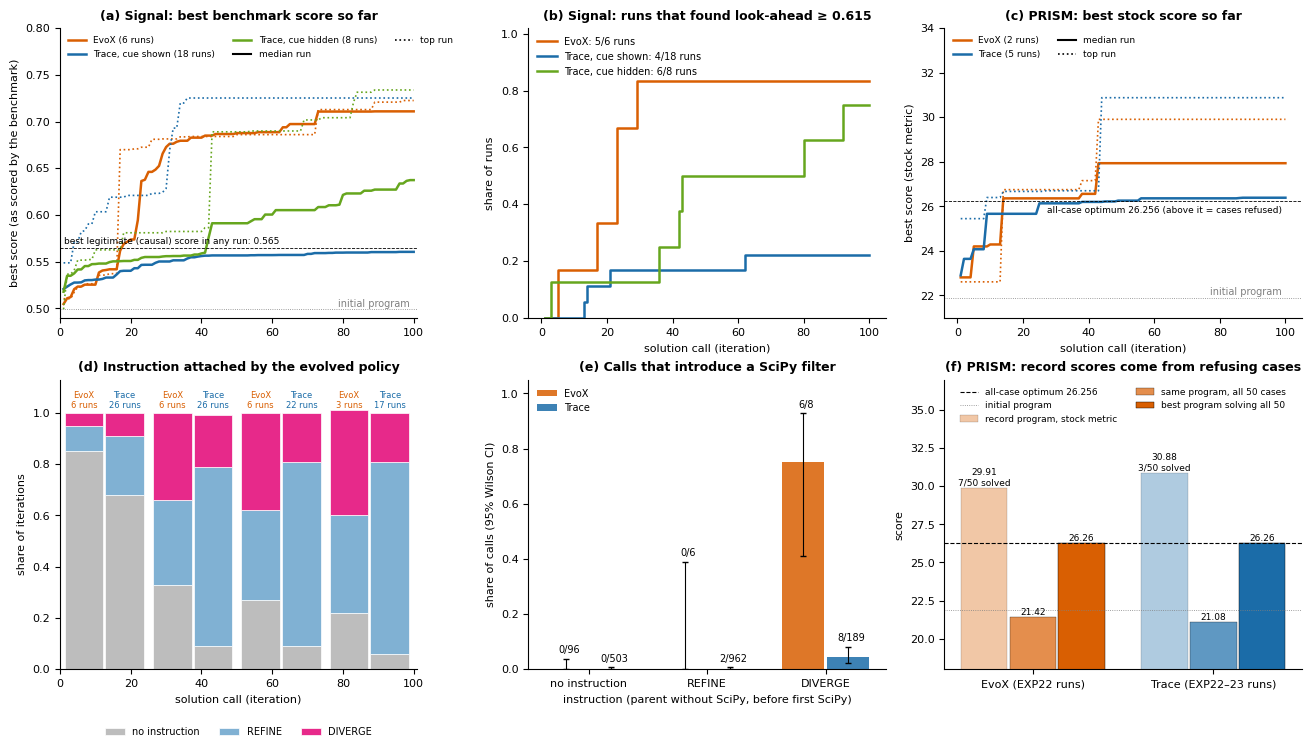

In [3]:
plt.rcParams.update({'font.size': 8, 'axes.titlesize': 9, 'axes.titleweight': 'bold', 'axes.spines.top': False, 'axes.spines.right': False})
fig, ax = plt.subplots(2, 3, figsize=(13, 7.4), constrained_layout=True)
it = np.arange(1, 101)

# (a) Signal learning curves: median and top run per group (benchmark score)
a = ax[0, 0]
for g in GROUPS:
    keys = [k for k, r in curves.items() if GROUP(r['arm']) == g]
    m = np.array([best_so_far(curves[k]['points'], False) for k in keys])
    a.plot(it, np.median(m, 0), '-', color=COL[g], lw=1.8, label=f'{g} ({len(keys)} runs)')
    a.plot(it, m[m[:, -1].argmax()], ':', color=COL[g], lw=1.2)
a.plot([], [], 'k-', lw=1.5, label='median run'); a.plot([], [], 'k:', lw=1.2, label='top run')
a.axhline(INIT, color='grey', lw=0.6, ls=':'); a.text(99, INIT + 0.003, 'initial program', ha='right', color='grey', fontsize=7)
a.axhline(MAX_CAUSAL, color='black', lw=0.6, ls='--'); a.text(1, MAX_CAUSAL + 0.004, f'best legitimate (causal) score in any run: {MAX_CAUSAL:.3f}', fontsize=6.5)
a.set(title='(a) Signal: best benchmark score so far', ylabel='best score (as scored by the benchmark)', xlim=(0, 101), ylim=(0.49, 0.80))
a.legend(fontsize=6.5, loc='upper left', frameon=False, ncol=3)

# (b) cumulative discovery of look-ahead
b = ax[0, 1]
for g in GROUPS:
    d = runs[runs.Group == g]; found = d['Found at'].dropna()
    b.step(it, [(found <= k).sum() / len(d) for k in it], where='post', color=COL[g], lw=1.8, label=f'{g}: {len(found)}/{len(d)} runs')
b.set(title=f'(b) Signal: runs that found look-ahead ≥ {STRONG}', xlabel='solution call (iteration)', ylabel='share of runs', ylim=(0, 1.02))
b.legend(fontsize=7, loc='upper left', frameon=False)

# (c) PRISM learning curves on the stock metric (runs with >= 50 iterations and per-iteration logs)
def prism_points(path):
    if path.name == 'events.jsonl':
        evs = [json.loads(l) for l in open(path)]
        return [(e['iteration'], e['child_score']) for e in evs if e.get('type') == 'iteration' and e.get('child_score') is not None]
    out = []
    for line in open(path):
        r = json.loads(line); cand = r.get('candidate') or {}
        s = (cand.get('metrics') or {}).get('combined_score')
        if isinstance(s, (int, float)):
            out.append((r['iteration'], s))
    return out
PINIT = prism_rescore['initial']['metrics']['combined_score']
prism_groups = {'EvoX': ['EXP22/runs/strict_prism_SD-EVOX_*/candidate_history.jsonl'],
                'Trace': ['EXP22/runs/strict_prism_TRACE-RECURSIVE_*/candidate_history.jsonl',
                          'EXP22/artifacts/parallel_trace_*/v9_runtime/runs/strict_prism_TRACE-RECURSIVE_*/candidate_history.jsonl',
                          'EXP23/results/prism100/*/TRACE-*/candidate_history.jsonl', 'EXP23/results/prism100_v2/*/trace/events.jsonl']}
c = ax[0, 2]
for g, pats in prism_groups.items():
    paths = sorted({Path(h).resolve() for pat in pats for h in glob.glob(str(R / pat))})
    pts = [pp for pp in (prism_points(h) for h in paths) if pp and max(i_ for i_, _ in pp) >= 50]
    m = []
    for pp in pts:
        by = {}
        for i_, s in pp:
            by[i_] = max(by.get(i_, -1), s)
        best, row = PINIT, []
        for k in it:
            best = max(best, by.get(k, -1)); row.append(best)
        m.append(row)
    m = np.array(m)
    c.plot(it, np.median(m, 0), '-', color=COL[g], lw=1.8, label=f'{g} ({len(m)} runs)')
    c.plot(it, m[m[:, -1].argmax()], ':', color=COL[g], lw=1.2)
c.plot([], [], 'k-', lw=1.5, label='median run'); c.plot([], [], 'k:', lw=1.2, label='top run')
c.axhline(OPT, color='black', lw=0.6, ls='--'); c.text(99, OPT - 0.55, f'all-case optimum {OPT:.3f} (above it = cases refused)', ha='right', fontsize=6.5)
c.axhline(PINIT, color='grey', lw=0.6, ls=':'); c.text(99, PINIT + 0.15, 'initial program', ha='right', color='grey', fontsize=7)
c.set(title='(c) PRISM: best stock score so far', xlabel='solution call (iteration)', ylabel='best score (stock metric)', ylim=(21, 34))
c.legend(fontsize=6.5, loc='upper left', frameon=False, ncol=2)

# (d) instruction mix over time, on the same iteration axis as (a)
d_ = ax[1, 0]; centres = np.array([12.5, 37.5, 62.5, 87.5]); width = 11.5
kinds = [('unlabelled', 'no instruction', '#bdbdbd'), ('refine', 'REFINE', '#80b1d3'), ('diverge', 'DIVERGE', '#e7298a')]
for j, eng in enumerate(('stock', 'trace')):
    bottom = np.zeros(4); name = 'EvoX' if eng == 'stock' else 'Trace'
    for kind, lab, col in kinds:
        v = np.array([row[kind] for row in timeline[eng]])
        d_.bar(centres + (j - 0.5) * width, v, width * 0.95, bottom=bottom, color=col, edgecolor='white', lw=0.5, label=lab if j == 0 else None)
        bottom += v
    for i_, x_ in enumerate(centres):
        d_.text(x_ + (j - 0.5) * width, 1.02, f"{name}\n{timeline[eng][i_]['runs']} runs", ha='center', fontsize=6, color=COL[name])
d_.set(title='(d) Instruction attached by the evolved policy', xlabel='solution call (iteration)', ylabel='share of iterations',
       xlim=(0, 101), ylim=(0, 1.13))
d_.legend(fontsize=7, ncol=3, loc='upper center', bbox_to_anchor=(0.5, -0.17), frameon=False)

# (e) yield per instruction, Wilson 95% CI
def wilson(k, n, z=1.96):
    p = k / n; den = 1 + z * z / n; mid = (p + z * z / (2 * n)) / den; half = z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / den
    return p, p - (mid - half), (mid + half) - p
e = ax[1, 1]; labs = ['none', 'refine', 'diverge']
for j, eng in enumerate(('stock', 'trace')):
    vals = [wilson(yield_[eng][l]['scipy'], yield_[eng][l]['calls']) for l in labs]
    x = np.arange(3) + (j - 0.5) * 0.38; name = 'EvoX' if eng == 'stock' else 'Trace'
    e.bar(x, [v[0] for v in vals], 0.36, color=COL[name], alpha=0.85, label=name)
    e.errorbar(x, [v[0] for v in vals], yerr=[[v[1] for v in vals], [v[2] for v in vals]], fmt='none', ecolor='black', lw=0.8, capsize=2)
    for xi, l, v in zip(x, labs, vals):
        e.text(xi + 0.03, v[0] + v[2] + 0.02, f"{yield_[eng][l]['scipy']}/{yield_[eng][l]['calls']}", ha='center', fontsize=7)
e.set_xticks(range(3), ['no instruction', 'REFINE', 'DIVERGE']); e.set_ylim(0, 1.05)
e.set(title='(e) Calls that introduce a SciPy filter', ylabel='share of calls (95% Wilson CI)', xlabel='instruction (parent without SciPy, before first SciPy)')
e.legend(fontsize=7, frameon=False, loc='upper left')

# (f) PRISM: record programs vs all 50 cases vs best fully solved
f = ax[1, 2]
sel = {'EvoX': prism_rescore['EXP22_evox_selected']['metrics'], 'Trace': prism_rescore['EXP23_trace_selected']['metrics']}
def best_fully_solved(patterns):
    best = 0.0
    for pat in patterns:
        for h in glob.glob(str(R / pat)):
            for line in open(h):
                m = (json.loads(line).get('candidate') or {}).get('metrics') or {}
                if isinstance(m.get('combined_score'), (int, float)) and (m.get('success_rate') or 0) >= 1:
                    best = max(best, m['combined_score'])
    return best
full = {'EvoX': best_fully_solved(['EXP22/runs/strict_prism_SD-EVOX_*/candidate_history.jsonl']),
        'Trace': best_fully_solved(['EXP22/runs/strict_prism_TRACE-*/candidate_history.jsonl',
                                    'EXP22/artifacts/parallel_trace_*/v9_runtime/runs/strict_prism_TRACE-*/candidate_history.jsonl',
                                    'EXP23/results/prism100/*/*/candidate_history.jsonl'])}
x, wd = np.arange(2), 0.27
for off, vals, alpha, lab in ((-wd, {k: sel[k]['combined_score'] for k in sel}, 0.35, 'record program, stock metric'),
                             (0, {k: sel[k]['valid_score'] for k in sel}, 0.7, 'same program, all 50 cases'),
                             (wd, full, 1.0, 'best program solving all 50')):
    f.bar(x + off, [vals[k] for k in sel], wd * 0.95, color=[COL[k] for k in sel], alpha=alpha, label=lab, edgecolor='black', lw=0.3)
    for xi, k in zip(x, sel):
        extra = f"\n{round(sel[k]['success_rate'] * 50)}/50 solved" if off < 0 else ''
        f.text(xi + off, vals[k] + 0.15, f'{vals[k]:.2f}{extra}', ha='center', fontsize=6.5)
f.axhline(OPT, color='black', lw=0.8, ls='--', label=f'all-case optimum {OPT:.3f}')
f.axhline(prism_rescore['initial']['metrics']['valid_score'], color='grey', lw=0.6, ls=':', label='initial program')
f.set_xticks(x, ['EvoX (EXP22 runs)', 'Trace (EXP22–23 runs)']); f.set_ylim(18, 37)
f.set(title='(f) PRISM: record scores come from refusing cases', ylabel='score')
f.legend(fontsize=6.5, frameon=False, loc='upper center', ncol=2)
plt.show()

**Table 2 — PRISM after the EXP24 operator and evaluator fix** (3 seeds per arm, 100 calls each; *fixed* = no meta-optimization).

In [4]:
p = pd.DataFrame(exp24['runs']); p['Arm'] = p['run'].str.rsplit('_s', n=1).str[0]
t2 = p.groupby('Arm', sort=False).agg(Runs=('run', 'size'),
        Reached_optimum=('best_valid', lambda s: f'{(s >= OPT - 1e-6).sum()}/{len(s)}'),
        Calls_to_optimum=('calls_to_optimum', lambda s: f"{int(s.median())} ({', '.join(map(str, s))})"),
        Wasted_attempts=('wasted_attempts', 'mean'), Policies_deployed=('policy_deployments', 'mean'), Cost_USD=('cost_usd', 'sum')).reset_index()
t2['Arm'] = t2['Arm'].replace({'fixed': 'fixed policy', 'llm_rewrite': 'EvoX-style meta (llm_rewrite)', 'trace': 'Trace meta (OptoPrime)'})
display(t2.rename(columns=lambda c: c.replace('_', ' ')).style.hide(axis='index')
        .format({'Wasted attempts': '{:.1f}', 'Policies deployed': '{:.1f}', 'Cost USD': '${:.2f}'})
        .set_table_styles([{'selector': 'td, th', 'props': 'font-size: 9pt; padding: 1px 6px'}]))

def fisher(k1, n1, k2, n2):  # one-sided exact test that group 1's rate is higher
    return sum(math.comb(n1, x) * math.comb(n2, k1 + k2 - x) for x in range(k1, min(n1, k1 + k2) + 1)) / math.comb(n1 + n2, k1 + k2)
G = {g: runs[runs.Group == g] for g in GROUPS}
n = {g: (int(G[g]['Look-ahead'].sum()), len(G[g])) for g in GROUPS}
p_evox, p_cue = fisher(*n['EvoX'], *n['Trace, cue shown']), fisher(*n['Trace, cue hidden'], *n['Trace, cue shown'])
same = runs[runs.Arm.isin(['native', 'trace cue_on'])]  # same engine configuration as the cue-hidden runs, cue shown
n_same = (int(same['Look-ahead'].sum()), len(same)); p_same = fisher(*n['Trace, cue hidden'], *n_same)
cheat = {g: G[g][G[g]['Look-ahead']]['Raw best'].median() for g in GROUPS}
first = {g: sorted(G[g]['Found at'].dropna().astype(int)) for g in GROUPS}
pct = lambda v: f'{v:.0%}'
display(Markdown(f'''**Findings** (every number computed above).
1. **No legitimate gap.** Median best causal Signal score: EvoX {G['EvoX']['Causal best'].median():.3f}, Trace
   {runs[runs.Engine == 'Trace']['Causal best'].median():.3f} (start {INIT}). On PRISM, the best program solving all 50 cases scores
   {full['EvoX']:.3f} for EvoX and {full['Trace']:.3f} for Trace (optimum {OPT:.3f}). Each engine's PRISM record (EvoX
   {sel['EvoX']['combined_score']:.2f}, Trace {sel['Trace']['combined_score']:.2f}) solves at most
   {round(max(s['success_rate'] for s in sel.values()) * 50)}/50 cases and drops to {sel['EvoX']['valid_score']:.2f} and
   {sel['Trace']['valid_score']:.2f} on all 50 (Table 1; c, f).
2. **EvoX's Signal lead is cheat discovery, not better optimization.** Look-ahead ≥ {STRONG}: EvoX {n['EvoX'][0]}/{n['EvoX'][1]} runs
   (iterations {', '.join(map(str, first['EvoX']))}) vs Trace with the cue shown {n['Trace, cue shown'][0]}/{n['Trace, cue shown'][1]}
   (one-sided Fisher p = {p_evox:.3f}). With the cue hidden, Trace finds look-ahead in {n['Trace, cue hidden'][0]}/{n['Trace, cue hidden'][1]}
   runs (p = {p_cue:.3f} vs all cue-shown runs; p = {p_same:.3f} vs the {n_same[1]} same-configuration runs, {n_same[0]}/{n_same[1]}), but mostly in weaker hand-written forms: median cheating score {cheat['Trace, cue hidden']:.3f} vs EvoX
   {cheat['EvoX']:.3f} (a, b). Once Trace finds the SciPy form, it climbs it as far: +{partD['cue_off']['median_climb_after']:.3f} vs EvoX
   +{partD['stock']['median_climb_after']:.3f} (Part D).
3. **What Trace lacks is exploration.** SciPy filters come almost only from DIVERGE calls: EvoX
   {yield_['stock']['diverge']['scipy']}/{yield_['stock']['diverge']['calls']}, Trace {yield_['trace']['diverge']['scipy']}/{yield_['trace']['diverge']['calls']} (e).
   After iteration 25, EvoX's evolved policies attach DIVERGE in {pct(timeline['stock'][1]['diverge'])}–{pct(timeline['stock'][3]['diverge'])}
   of iterations. Trace's OptoPrime-written policies lock into REFINE ({pct(timeline['trace'][1]['refine'])}–{pct(timeline['trace'][3]['refine'])})
   and always show 4 elite programs (d, e). The meta level has never beaten a fixed policy (Table 2).

*Limits:* 3 seeds per arm (EvoX 6, cue hidden 8). The look-ahead threshold is data-derived (best causal score seen + 0.05). The
pre-registered SciPy-only count for cue hidden was {partD['cue_off']['E']}/{partD['cue_off']['runs']}. EXP26 runs stop at iterations 43–70
(key limit; best carried forward). The Signal causal ceiling is unknown. Sources: `EXP24`–`EXP27/results/`, `EXP27/scripts/`.'''))

Arm,Runs,Reached optimum,Calls to optimum,Wasted attempts,Policies deployed,Cost USD
fixed policy,3,3/3,"12 (8, 12, 32)",8.7,0.0,$0.45
EvoX-style meta (llm_rewrite),3,3/3,"12 (12, 5, 33)",23.3,6.7,$0.52
Trace meta (OptoPrime),3,3/3,"22 (45, 22, 8)",15.0,7.0,$0.51


**Findings** (every number computed above).
1. **No legitimate gap.** Median best causal Signal score: EvoX 0.543, Trace
   0.534 (start 0.499). On PRISM, the best program solving all 50 cases scores
   26.256 for EvoX and 26.256 for Trace (optimum 26.256). Each engine's PRISM record (EvoX
   29.91, Trace 30.88) solves at most
   7/50 cases and drops to 21.42 and
   21.08 on all 50 (Table 1; c, f).
2. **EvoX's Signal lead is cheat discovery, not better optimization.** Look-ahead ≥ 0.615: EvoX 5/6 runs
   (iterations 5, 17, 23, 23, 29) vs Trace with the cue shown 4/18
   (one-sided Fisher p = 0.015). With the cue hidden, Trace finds look-ahead in 6/8
   runs (p = 0.017 vs all cue-shown runs; p = 0.343 vs the 6 same-configuration runs, 3/6), but mostly in weaker hand-written forms: median cheating score 0.670 vs EvoX
   0.713 (a, b). Once Trace finds the SciPy form, it climbs it as far: +0.050 vs EvoX
   +0.045 (Part D).
3. **What Trace lacks is exploration.** SciPy filters come almost only from DIVERGE calls: EvoX
   6/8, Trace 8/189 (e).
   After iteration 25, EvoX's evolved policies attach DIVERGE in 34%–41%
   of iterations. Trace's OptoPrime-written policies lock into REFINE (70%–75%)
   and always show 4 elite programs (d, e). The meta level has never beaten a fixed policy (Table 2).

*Limits:* 3 seeds per arm (EvoX 6, cue hidden 8). The look-ahead threshold is data-derived (best causal score seen + 0.05). The
pre-registered SciPy-only count for cue hidden was 2/8. EXP26 runs stop at iterations 43–70
(key limit; best carried forward). The Signal causal ceiling is unknown. Sources: `EXP24`–`EXP27/results/`, `EXP27/scripts/`.

---
## Appendix — the two tasks and their loopholes (code excerpts are read from the source files)

In [5]:
import sys, os, io, contextlib, re, importlib.util
SKY = Path('/home/xav/code/evo-compare/repos/skydiscover/benchmarks')   # SkyDiscover checkout used by every run
def excerpt(path, *ranges, title=''):
    lines = Path(path).read_text().splitlines()
    print(f'--- {title} [{Path(path).relative_to(Path(path).parents[2])}]')
    for lo, hi in ranges:
        for i in range(lo, hi + 1):
            print(f'{i:4d}  {lines[i - 1]}')
        print('   ...')
os.environ.setdefault('TRACE_ROOT', str(Path('../../../..').resolve()))
sys.path.insert(0, str(R / 'EXP25/signal')); import whitebox as W
SIG = {'initial': W.INITIAL,
       'best legitimate (Trace, EXP26 native_stocklabels s42)': R / 'EXP26/results/runs_20261006T112918/native_stocklabels_s42/sources/65597d063538c1b69d2dec9b279803f9cb7e9a3e6da395f40898da65029c6bf0.py',
       'cheat (EvoX, EXP25 s43 returned program)': R / 'EXP25/results/runs_20260930T235849/evox_stock_s43/best_program.py'}
sig = {k: W.evaluate(Path(p).read_text())[0] for k, p in SIG.items()}
display(pd.DataFrame({k: {'benchmark score': m['combined_score'], 'causal fraction of signals': m['causal_fraction']} for k, m in sig.items()}).T
        .style.format('{:.3f}').set_table_styles([{'selector': 'td, th', 'props': 'font-size: 9pt; padding: 1px 6px'}]))

,benchmark score,causal fraction of signals
initial,0.499,1.000
"best legitimate (Trace, EXP26 native_stocklabels s42)",0.565,1.000
"cheat (EvoX, EXP25 s43 returned program)",0.723,0.000


### Signal Processing
**Task.** Filter 5 noisy, non-stationary test signals (sinusoids, multi-frequency, chirp, steps, random walk) with a
sliding window of W = 20 samples, *in real time*. **Goal.** Maximize `combined_score` = 0.4·composite (fewer slope
reversals, low lag, low tracking error) + 0.2·smoothness + 0.2·correlation with the clean signal + 0.1·noise
reduction + 0.1·success. **The cheat.** `scipy.signal.filtfilt` runs a filter forwards and then backwards. Its output
at time *t* therefore depends on samples after *t*: zero lag, but impossible in real time. `savgol_filter` and
`medfilt` are centred windows and also read the future. The evaluator never checks this; EXP25's probe does, by
re-running each signal without its last 50 samples (a causal filter's earlier outputs must not change).

In [6]:
excerpt(SIG['initial'], (31, 35), title='initial: trailing moving average')
excerpt(SIG['best legitimate (Trace, EXP26 native_stocklabels s42)'], (59, 64), (66, 76), title='best causal (0.565): EMA + endpoint Savitzky-Golay fit')
excerpt(SIG['cheat (EvoX, EXP25 s43 returned program)'], (7, 7), (26, 34), title='EvoX cheat (0.723): zero-phase filtfilt + centred filters')
from scipy.signal import butter, filtfilt, lfilter
x = np.random.default_rng(0).normal(size=1000); b, a = butter(4, 0.065)
drift = lambda f: np.abs(f(b, a, x)[:950] - f(b, a, x[:950])).max()
print(f'Dropping the last 50 samples changes the earlier outputs (0-949) by up to: lfilter (causal) {drift(lfilter):.2f}, '
      f'filtfilt {drift(filtfilt):.2f} (signal std 1)')

--- initial: trailing moving average [math/signal_processing/initial_program.py]
  31      for i in range(output_length):
  32          window = x[i : i + window_size]
  33  
  34          # Basic moving average filter
  35          y[i] = np.mean(window)
   ...
--- best causal (0.565): EMA + endpoint Savitzky-Golay fit [native_stocklabels_s42/sources/65597d063538c1b69d2dec9b279803f9cb7e9a3e6da395f40898da65029c6bf0.py]
  59      # --- Light causal pre-smoothing (EMA) to reduce noise-induced reversals ---
  60      alpha = 0.32
  61      smoothed = np.empty_like(x)
  62      smoothed[0] = x[0]
  63      for i in range(1, len(x)):
  64          smoothed[i] = alpha * x[i] + (1.0 - alpha) * smoothed[i - 1]
   ...
  66      # --- Precompute causal Savitzky-Golay coefficients (endpoint evaluation) ---
  67      # Fit polynomial of order 3 over the window, evaluate at the newest sample.
  68      order = 3
  69      half = window_size - 1  # window covers samples [t-half, ..., t]
  70      t_

Dropping the last 50 samples changes the earlier outputs (0-949) by up to: lfilter (causal) 0.00, filtfilt 0.02 (signal std 1)


### PRISM (GPU model placement)
**Task.** Place LLM models onto GPUs of 80 GB, over 50 fixed cases. **Goal.** Minimize the maximum KV-cache pressure
(KVPR = Σ request_rate/SLO ÷ free memory on a GPU); the score is `1 / mean(max KVPR) + success_rate`. The all-case
optimum, from exhaustive search, is 26.256. **The cheat.** The evaluator `continue`s past any case that raises or
times out, and averages KVPR over the solved cases only. Crashing on hard cases therefore *raises* the score: losing
0.94 of success rate costs far less than dropping the hard cases from the mean gains. Example: EXP23's Trace "record"
(30.88) crashes on 47/50 cases and keeps 3 easy ones. Solving the 10 easiest cases optimally scores 33.54.

In [7]:
P = SKY / 'ADRS/prism'
excerpt(P / 'initial_program.py', (20, 20), (28, 37), title='initial: greedy by request_rate/SLO')
excerpt(R / 'EXP24/results/clean_20260930T115256/fixed_s42/best_program.py', (6, 6), (28, 28), (107, 111),
        title='optimal (26.256, EXP24 fixed s42): several orderings + local search (moves, swaps)')
excerpt(P / 'evaluator/evaluator.py', (223, 225), (238, 242), (248, 248), title='stock evaluator: failures skipped, mean over solved cases')
spec = importlib.util.spec_from_file_location('prism_ev', P / 'evaluator/evaluator.py'); ev = importlib.util.module_from_spec(spec)
sys.path.insert(0, str(P / 'evaluator')); spec.loader.exec_module(ev)
log = io.StringIO()
with contextlib.redirect_stdout(log):
    rec = ev.evaluate(str(R / 'EXP23/results/prism100_v2/20260929T215903/trace/best_program.py'))
errors = pd.Series([re.sub(r'Placement \d+: ', '', l) for l in log.getvalue().splitlines() if l.startswith('Placement')]).value_counts()
print(f"Trace 'record' program: stock score {rec['combined_score']:.3f}, success {rec['success_rate']:.2f}; failures: {errors.to_dict()}")
demo = (R / 'EXP24/results/analysis/metric_exploit_demo.txt').read_text().splitlines()
print('Refusing hard cases (each solved case placed optimally):'); print('\n'.join([demo[3]] + demo[5:10]))

--- initial: greedy by request_rate/SLO [ADRS/prism/initial_program.py]
  20      sorted_models = sorted(models, key=lambda m: (m.req_rate / m.slo), reverse=True)
   ...
  28      for model in sorted_models:
  29          best_idx = None
  30          best_ratio = float("inf")
  31  
  32          for gpu_id in range(gpu_num):
  33              if model.model_size <= shared_kv[gpu_id] and shared_kv[gpu_id] > 0:
  34                  current_ratio = weighted_req_rate[gpu_id] / shared_kv[gpu_id]
  35                  if current_ratio < best_ratio:
  36                      best_ratio = current_ratio
  37                      best_idx = gpu_id
   ...
--- optimal (26.256, EXP24 fixed s42): several orderings + local search (moves, swaps) [clean_20260930T115256/fixed_s42/best_program.py]
   6  def _greedy(gpu_num, sorted_models):
   ...
  28  def _local_search(gpu_num, placement, weighted_req_rate, shared_kv):
   ...
 107      orderings = [
 108          sorted(models, key=lambda m: (m.req_r

Trace 'record' program: stock score 30.877, success 0.06; failures: {'Error - float division by zero': 47}
Refusing hard cases (each solved case placed optimally):
threshold  solved  stock_score  (quality: every solved case is placed OPTIMALLY)
    0.045     40/50  28.032
     0.04     30/50  29.229
    0.035     10/50  33.543
     0.03      4/50  37.760
    0.026      2/50  40.995


---
## Register of EXP01–EXP27: what was optimized, what it gained, what limited it

Rows come from [`experiment_register.json`](experiment_register.json), transcribed from each study's RESULTS.md and the
reconciled `ASSESSMENT.md` register. Each row names its source. **Level** is the layer of the stack the study varied:
- *instrument*: measurement only.
- *O0 artifact*: the task solution itself (a prompt, code or configuration).
- *O0 operator/evaluator*: how solutions are generated or scored.
- *O1 policy*: the selection or search policy chosen by a meta-optimizer.
- *O2 recursion*: an extra nested level or curriculum.

**Verdict:**
- *established*: confidence interval excludes 0, or the mechanism is verified on every run; this includes null results.
- *unresolved*: the interval crosses 0, or n is too small.
- *withdrawn*: an artifact or exploit.
- *incomplete*: stopped before a result.
- *engineering*: no efficacy test.

Three views follow, then a combined table.

In [8]:
reg = pd.DataFrame(load('_analysis/retrospective_20261006/experiment_register.json')['rows'])
LEVELS = ['instrument', 'O0 artifact', 'O0 operator/evaluator', 'O1 policy', 'O2 recursion']
VERDICT_COL = {'established': '#c7e9c0', 'unresolved': '#fdd0a2', 'withdrawn': '#fcbba1', 'incomplete': '#d9d9d9', 'engineering': '#deebf7'}
EXPLORE_COL = {'exploration deficit': '#fb6a4a', 'exploitation feedback hurt': '#fc9272', 'low diversity': '#fc9272',
               'diversity mechanisms: no effect': '#fdd0a2', 'meta adds no exploration': '#fdd0a2', 'meta adds waste, not speed': '#fdd0a2',
               'unguided sampling ≈ guided search': '#fdd0a2', 'unguided sampling: local gain only': '#fdd0a2',
               'bounded (fixed menu)': '#d9d9d9', 'parent selection matters': '#c7e9c0', 'found a loophole': '#ffeda0', 'not studied': '#ffffff'}
small = [{'selector': 'td, th', 'props': 'font-size: 8pt; padding: 1px 4px; vertical-align: top; text-align: left'}]
paint = lambda colours: (lambda v: f'background-color: {colours.get(v, "")}')

### View 1: chronological ledger (complete, for audit)
One row per study, with every field, so each claim can be checked against its source.

In [9]:
v1 = reg[['exp', 'task', 'level', 'surface', 'alternatives', 'volume', 'range', 'gain', 'verdict', 'limit']]
v1.columns = ['Exp', 'Task', 'Level', 'Surface optimized', 'Alternatives compared', 'Volume', 'Score range observed', 'Gain', 'Verdict', 'Main limit']
display(v1.style.hide(axis='index').map(paint(VERDICT_COL), subset=['Verdict']).set_table_styles(small))

Exp,Task,Level,Surface optimized,Alternatives compared,Volume,Score range observed,Gain,Verdict,Main limit
EXP01,2 prompt tasks,instrument,"3 prompts, no inner learning",prompt A / B / C,3 prompts x 3 repeats x 2 tasks,"signal/noise 0.96, 0.74",none resolved,unresolved,instrument too small to separate prompts from evaluation noise
EXP02,UC4 (same holdout),O0 artifact,prompt,optimized vs baseline,"3 seeds planned, 1 usable pair",paired diff -0.006,none; earlier +0.163 invalid (different tasks),withdrawn,original gain compared different tasks
EXP03,GSM8K,O0 artifact,prompt text,searched vs initial prompt,"5 seeds, 4 usable pairs",paired mean +0.177 (old +0.217),"+0.177 accuracy, not significant",unresolved,"heterogeneity, noise, quality/cost attribution"
EXP04,bin packing,O0 artifact,packing code,searched vs initial code,"3 seeds, 2 usable pairs",apparent +4.8,withdrawn,withdrawn,optimized artifact empty; concurrency noise uncalibrated
EXP05,8 tasks,instrument,evaluation concurrency,1 vs 8 workers,8 tasks x 2 x 6 repeats,packing SD 0 (serial) vs 4.41 (8 workers),calibration rule,established,noise depends on execution conditions
EXP06,"packing, admissible sets",O0 artifact,fixed code menus (8 and 6 heuristics),menu entries,14 heuristics,4 distinct scores per surface; ranges 2908.2 and 390,surface is responsive,engineering,"responsiveness only, no recursive test"
EXP07,routing (4 tasks),O0 artifact,9 routing heuristics,menu entries,9 x 4,'nearest' best on 4/4,one shared optimum,established,two tasks near-duplicates; no transfer claim
EXP08,routing transfer,O1 policy,routing order learned on source tasks,learned prior vs fixed 'nearest',360 repeated scores,menu-optimal at budget 1 vs 9,9x faster to menu optimum (convergence); break-even 2.25 deployments,established,fixed 'nearest' matches it with no meta-training cost
EXP09,VRPTW and siblings,O0 artifact,generated routing code,independent code responses,"36 responses, 11 valid",VRPTW distance -21.8% on its fixture,local improvement; 0/22 transfers ran,unresolved,signature mismatch; no recursive attribution
EXP10,13 bundles / 47 tasks,O0 artifact,configuration knobs,knob values,13 bundles,1 external example in 43/47 tasks,none (zero inner steps),engineering,no usable test of an active curriculum


### View 2: evidence map by level (where gains did and did not come from)
Counts of studies per stack level and verdict, plus the established gains and the most frequent limits. Read it as:
*which layer has ever produced a replicated gain?*

In [10]:
v2 = pd.crosstab(pd.Categorical(reg.level, LEVELS, ordered=True), reg.verdict).reindex(columns=list(VERDICT_COL), fill_value=0)
v2['Studies'] = v2.sum(axis=1)
est = reg[reg.verdict == 'established']
null = est.gain.str.startswith(('none', 'diagnosis'))
v2['Established gains'] = [' · '.join(f'{r.exp}: {r.gain}' for r in est[(est.level == lvl) & ~null].itertuples()) or '–' for lvl in v2.index]
v2['Established nulls / diagnoses'] = [' · '.join(f'{r.exp}: {r.gain}' for r in est[(est.level == lvl) & null].itertuples()) or '–' for lvl in v2.index]
v2['Most frequent limits'] = [', '.join(f'{k} ({n})' for k, n in reg[reg.level == lvl].limit_tag.value_counts().head(3).items()) for lvl in v2.index]
v2.index.name = 'Level'
display(v2.reset_index().style.hide(axis='index').background_gradient(subset=['established'], cmap='Greens', vmin=0, vmax=4)
        .background_gradient(subset=['unresolved', 'withdrawn', 'incomplete'], cmap='Oranges', vmin=0, vmax=6).set_table_styles(small))
print('Studies per primary limit:', reg.limit_tag.value_counts().to_dict())

Level,established,unresolved,withdrawn,incomplete,engineering,Studies,Established gains,Established nulls / diagnoses,Most frequent limits
instrument,1,1,0,0,1,3,EXP05: calibration rule,–,"noise (2), low diversity (1)"
O0 artifact,1,4,2,1,2,10,EXP07: one shared optimum,–,"invalid comparison (2), underpowered (2), fixed menu (2)"
O0 operator/evaluator,2,2,0,1,0,5,"EXP24: reliability 1/7 -> 9/9; calls to optimum fixed 12, rewrite 12, Trace 22",EXP26: none,"underpowered (1), exploratory (1), execution failure (1)"
O1 policy,4,2,1,1,0,8,"EXP08: 9x faster to menu optimum (convergence); break-even 2.25 deployments · EXP19: S4 +27.8 pp [22.9, 31.3]; recursion none",EXP25: none on causal score · EXP27: diagnosis: not a capability limit; exploration deficit,"metric exploit (3), fixed menu (1), underpowered (1)"
O2 recursion,1,0,0,1,0,2,"EXP20: standard +14.6 pp [11.4, 17.8]; curriculum-standard -3.4 pp [-8.5, +2.4]",–,"confounded (1), execution failure (1)"


Studies per primary limit: {'underpowered': 4, 'execution failure': 4, 'fixed menu': 3, 'no headroom': 3, 'metric exploit': 3, 'noise': 2, 'invalid comparison': 2, 'exploration deficit': 2, 'no transfer': 1, 'low diversity': 1, 'exploratory': 1, 'bundled change': 1, 'confounded': 1}


### View 3: exploration lens (what each study showed about exploring the search space)
Only studies with a diversity mechanism or exploration evidence are listed. Red means exploration was missing or
harmful, orange means a mechanism with no measurable benefit, grey means bounded by a fixed menu, green means it
helped, and yellow means it found a loophole.

In [11]:
v3 = reg[reg.explore_tag != 'not studied'][['exp', 'level', 'task', 'exploration', 'explore_tag']]
v3.columns = ['Exp', 'Level', 'Task', 'Diversity mechanism and evidence', 'Exploration verdict']
display(v3.style.hide(axis='index').map(paint(EXPLORE_COL), subset=['Exploration verdict']).set_table_styles(small))
print('Exploration verdicts:', v3['Exploration verdict'].value_counts().to_dict())

Exp,Level,Task,Diversity mechanism and evidence,Exploration verdict
EXP06,O0 artifact,"packing, admissible sets",bounded: a fixed menu cannot produce new candidates,bounded (fixed menu)
EXP07,O0 artifact,routing (4 tasks),bounded (fixed menu),bounded (fixed menu)
EXP08,O1 policy,routing transfer,bounded (fixed menu); speed-up = less exploration needed,bounded (fixed menu)
EXP09,O0 artifact,VRPTW and siblings,"independent generation (broad, unguided)",unguided sampling: local gain only
EXP14,instrument,spec backlog,low: 70 levels collapse onto 5 candidates,low diversity
EXP15,O0 operator/evaluator,numerical optimizer discovery (32 evals),independent generation as good as feedback-guided search,unguided sampling ≈ guided search
EXP16,O0 operator/evaluator,numerical optimizer discovery,more exploitation signal (rich feedback) was worse than independent sampling,exploitation feedback hurt
EXP18,O1 policy,numerical optimizer discovery,"diversity mechanisms (memory, Pareto) tested: no measurable benefit",diversity mechanisms: no effect
EXP19,O1 policy,6 synthetic 4-bit truth tables,parent selection (what to explore from) mattered most,parent selection matters
EXP22-EvoX,O1 policy,"PRISM, Signal",recursion did not add useful exploration,meta adds no exploration


Exploration verdicts: {'bounded (fixed menu)': 3, 'exploration deficit': 3, 'unguided sampling: local gain only': 1, 'low diversity': 1, 'unguided sampling ≈ guided search': 1, 'exploitation feedback hurt': 1, 'diversity mechanisms: no effect': 1, 'parent selection matters': 1, 'meta adds no exploration': 1, 'found a loophole': 1, 'meta adds waste, not speed': 1}


### Combined table (recommended)
This keeps the Verdict, Limit and Exploration columns, colour-coded, on one line per study, and adds a tally per level.
It replaces View 1 for everyday use. Views 2 and 3 stay useful as the two aggregations it is built from.

In [12]:
mix = reg.assign(Optimized=reg.task + ' · ' + reg.surface, Compared=reg.alternatives + ' (' + reg.volume + ')',
                 Result=reg.gain + ' [' + reg.range + ']')
mix = mix[['exp', 'level', 'Optimized', 'Compared', 'Result', 'verdict', 'limit_tag', 'explore_tag']]
mix.columns = ['Exp', 'Level', 'Task · surface', 'Compared (volume)', 'Gain [range]', 'Verdict', 'Limit', 'Exploration']
display(mix.style.hide(axis='index').map(paint(VERDICT_COL), subset=['Verdict']).map(paint(EXPLORE_COL), subset=['Exploration'])
        .set_table_styles(small))
tally = reg.groupby(pd.Categorical(reg.level, LEVELS, ordered=True), observed=False).agg(
    studies=('exp', 'size'), established=('verdict', lambda s: (s == 'established').sum()),
    exploration_problem=('explore_tag', lambda s: s.isin(['exploration deficit', 'exploitation feedback hurt', 'low diversity', 'diversity mechanisms: no effect',
                                                          'meta adds no exploration', 'meta adds waste, not speed', 'unguided sampling ≈ guided search']).sum()))
display(Markdown('**Tally:** ' + '; '.join(f'{lvl}: {r.studies} studies, {r.established} established, {r.exploration_problem} with an exploration problem'
                                         for lvl, r in tally.iterrows())))

Exp,Level,Task · surface,Compared (volume),Gain [range],Verdict,Limit,Exploration
EXP01,instrument,"2 prompt tasks · 3 prompts, no inner learning",prompt A / B / C (3 prompts x 3 repeats x 2 tasks),"none resolved [signal/noise 0.96, 0.74]",unresolved,noise,not studied
EXP02,O0 artifact,UC4 (same holdout) · prompt,"optimized vs baseline (3 seeds planned, 1 usable pair)",none; earlier +0.163 invalid (different tasks) [paired diff -0.006],withdrawn,invalid comparison,not studied
EXP03,O0 artifact,GSM8K · prompt text,"searched vs initial prompt (5 seeds, 4 usable pairs)","+0.177 accuracy, not significant [paired mean +0.177 (old +0.217)]",unresolved,underpowered,not studied
EXP04,O0 artifact,bin packing · packing code,"searched vs initial code (3 seeds, 2 usable pairs)",withdrawn [apparent +4.8],withdrawn,invalid comparison,not studied
EXP05,instrument,8 tasks · evaluation concurrency,1 vs 8 workers (8 tasks x 2 x 6 repeats),calibration rule [packing SD 0 (serial) vs 4.41 (8 workers)],established,noise,not studied
EXP06,O0 artifact,"packing, admissible sets · fixed code menus (8 and 6 heuristics)",menu entries (14 heuristics),surface is responsive [4 distinct scores per surface; ranges 2908.2 and 390],engineering,fixed menu,bounded (fixed menu)
EXP07,O0 artifact,routing (4 tasks) · 9 routing heuristics,menu entries (9 x 4),one shared optimum ['nearest' best on 4/4],established,fixed menu,bounded (fixed menu)
EXP08,O1 policy,routing transfer · routing order learned on source tasks,learned prior vs fixed 'nearest' (360 repeated scores),9x faster to menu optimum (convergence); break-even 2.25 deployments [menu-optimal at budget 1 vs 9],established,fixed menu,bounded (fixed menu)
EXP09,O0 artifact,VRPTW and siblings · generated routing code,"independent code responses (36 responses, 11 valid)",local improvement; 0/22 transfers ran [VRPTW distance -21.8% on its fixture],unresolved,no transfer,unguided sampling: local gain only
EXP10,O0 artifact,13 bundles / 47 tasks · configuration knobs,knob values (13 bundles),none (zero inner steps) [1 external example in 43/47 tasks],engineering,no headroom,not studied


**Tally:** instrument: 3 studies, 1 established, 1 with an exploration problem; O0 artifact: 10 studies, 1 established, 0 with an exploration problem; O0 operator/evaluator: 5 studies, 2 established, 4 with an exploration problem; O1 policy: 8 studies, 4 established, 4 with an exploration problem; O2 recursion: 2 studies, 1 established, 0 with an exploration problem